#Universidad del Gran Rosario - UGR
#Ingeniería del Software
##Trabajo Práctico
###Introducción a las metodologías y procesos de Ciencia de Datos
####Docentes: Ing. Ignacio Sanseovich - Lic. Briant Gauna

####Estudiantes:
* Evelin Senghaas
* Matias Ortiz
* Joel Heduerd Benavidez
* Hernan Vieira
* Gabriel Ricardo Macus
* Sebastian Fuentes
* Sonia Ferreyra
* Marco Fouad
* Ariel Diaz


###Estudio de Caso
Este trabajo se basa en la aplicación de una metodología de Minería de Datos y su implementación en una solución de software.

Lo que se espera es que el grupo desarrolle:
* Una metodología clara de cómo se procesarán los datos y su resultado e interpretación.
* Las vistas y montaje de la solución de software que dará vida a esta metodología para conectar el proceso de datos con el usuario final.

Elegiremos trabajar con la Metodología CRISP-DM (Cross-Industry Standard Process for Data Mining).

La entrega constará de:
* Esta notebook completa
* El link desde donde se puede acceder al producto de software implementado

##Fases del Trabajo:

##Fase #1: Comprensión del Negocio / Business Understanding:
Esta fase inicial se centra en comprender los objetivos y requisitos del proyecto desde una perspectiva de negocio, para luego convertir este conocimiento en una definición del problema de minería de datos y un plan preliminar diseñado para lograr los objetivos.

* Elegí un problema de negocio que puedas resolver con datos. Describilo brevemente.
* ¿Cuál es el objetivo principal del análisis? Elaborá un objetivo general y algunos específicos. Te ayudarán a clasificar las tareas más adelante.
* Enumerá los distintos Stakeholders del negocio donde está inmerso el problema.
* ¿Qué impacto tendrá la solución en el negocio o en la toma de decisiones? Justificála realización del estudio desde la perspectiva de cada Stakeholder enumerado anteriormente.

###Contexto de negocio
La empresa RavenStack ofrece a sus clientes un software por suscripción, basado en una modalidad de ofrecimiento que consiste en brindar una prueba gratis que logre que conozcan y prueben el sistema, para finalmente suscribirse al mismo.

### Problema de Negocio
Por su modo de operar, priorizan la retención de clientes, ya que esto afecta directamente en sus ingresos.
RavenStack cuenta con información de sus clientes, de sus suscripciones, formas de uso, problemáticas que llegan al área de soporte y cancelaciones, sin embargo no con un análisis profundo acerca del comportamiento de sus usuarios, por lo que no pueden realizar predicciones certeras.



###Objetivo de Negocio
Actualmente están pasando por una temporada de bajas de clientes (churn), por lo que requieren de un profundo análisis de datos con el objetivo de distinguir en el comportamiento de los usuarios los factores que influyen en la cancelación de la suscripción, con el fin de identificar oportunidades de mejora, que permitan reducir la tasa de baja de clientes y favorecer la retención de los mismos.

###Objetivos específicos
*   Identificar las variables relacionadas con el churn
*   Predecir la probabilidad de cancelación de cada cliente en específico, según su comportamiento
*   Analizar el impacto de la baja de clientes en los ingresos recurrentes
*   Determinar el Top 5 de factores de comportamiento que anticipan una baja con al menos 3 meses de antelación
* Tratar de establecer un modelo predictivo con un nivel de precisión (accuracy) suficiente para identificar clientes en riesgo


###Impacto de la solución en el Negocio
La implementación de esta solución permitirá transformar datos en decisiones estratégicas orientadas a la retención de clientes, generando un impacto directo en los ingresos y la eficiencia operativa de la empresa.


###Justificación por Stakeholder
<table>
  <tr>
    <th>Stakeholder</th>
    <th>Justificación</th>
  </tr>
  <tr>
    <td>Dirección de la empresa</td>
    <td>Comprender cómo el churn impacta en los ingresos y tomar decisiones estratégicas para el crecimiento del negocio.</td>
  </tr>
  <tr>
    <td>Marketing</td>
    <td>Optimizar campañas de captación apuntando a las empresas que tengan más similitud con los clientes permanentes.
</td>
  </tr>
    <tr>
    <td>Área de desarrollo</td>
    <td>Identificar qué funcionalidades generan mayor engagement y cuáles requieren mejoras, chequear si hay 'puntos de fricción' <br><br> en el software (bugs recurrentes o falta de uso de una feature clave) que estén correlacionados con la baja de clientes.</td>
  </tr>
    <tr>
    <td>Área de soporte</td>
    <td>Detectar clientes en riesgo, según las problemáticas que les reporten y priorizar la cola de atención de tickets basándose en <br><br> el score de riesgo de churn del cliente.
</td>
  </tr>
    <tr>
    <td>Clientes</td>
    <td>El análisis permitirá mejorar su experiencia, reducir fricciones en el uso del producto y ofrecer un servicio más alineado a sus necesidades.
    </td>
  </tr>
</table>

---
## Fase #2 - Comprensión de los Datos / Data Understanding

### Metodología de adquisición de datos

Los datos provienen del dataset público **RavenStack SaaS Subscription & Churn Analytics**
(Kaggle, licencia MIT, autor: River @ Rivalytics).

El dataset es completamente sintético - generado con Python (pandas, numpy,
uuid) con lógica temporal validada (signup ≤ subscription ≤ churn) y distribuciones
estadísticas realistas (exponencial y Poisson). Simula una arquitectura de datos operacional
real con 5 tablas relacionales.

Se descarga por codigo con
`kagglehub`.

### Construcción del set de datos

El dataset no entrega una tabla analítica directa, sino que esta se debera construir mediante joins relacionales
entre las 5 fuentes, agregando métricas de comportamiento a nivel de cuenta,
para obtener un vector de features por `account_id`.

**Esquema relacional:**
```
accounts (500 filas)  ──┬── subscriptions (5000 filas)  ──── feature_usage (25.000 filas)
                        ├── churn_events (600 filas)
                        └── support_tickets (2000 filas)
```

Integridad referencial garantizada por diseño: todos los `account_id` y `subscription_id`
tienen correspondencia completa entre tablas (sin huérfanos).

### Desafíos que afectan la calidad de los datos

- `end_date` en subscriptions: **90.3% nulos** - intencional, indica suscripciones activas
  (sin fecha de cierre). No es dato faltante.
- `feedback_text` en churn_events: **24.7% nulos** - campo opcional, clientes que no dejaron
  comentario al cancelar.
- `satisfaction_score` en support_tickets: **41.3% nulos** - tickets cerrados sin calificación
  del cliente.
- `auto_renew_flag`: 80% true por diseño - distribución sesgada, baja varianza predictiva.
- **Reactivaciones:** 10% de churn_events corresponde a cuentas que cancelaron y volvieron -
  requiere tratamiento especial para no contar como churn doble.
- **Granularidad mixta:** usage y tickets son por evento; se deben agregar a nivel cuenta
  para el modelo.
- **Dato sintético:** las distribuciones son estadísticamente realistas pero no reflejan
  comportamiento de usuarios reales - limita la generalización del modelo a producción.

### Fases y tareas

- (2.1) **Adquisición:** Descarga via `kagglehub`, carga de 5 CSVs
- (2.2) **Exploración:** Shape, dtypes, nulls por tabla
- (2.3) **Verificación:** Integridad referencial entre tablas
- (2.4) **Construcción:** Agregaciones y joins para armar el dataset analítico maestro
- **Limpieza inicial:** Imputación de nulos por ausencia de actividad

## 2.1 - Adquisición de Datos

En esta etapa configuramos las bibliotecas de trabajo y realizamos la descarga
del dataset directamente desde Kaggle mediante `kagglehub`, que gestiona
autenticación y caché automáticamente. No requiere descarga manual de archivos.

El resultado son 5 archivos CSV que cargaremos en variables individuales
para su posterior exploración.

In [34]:
# ── Librerías ────────────────────────────────────────────────────────────────
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [2]:
# Descarga del dataset desde Kaggle
# kagglehub gestiona la autenticación y guarda en caché local
path = kagglehub.dataset_download("rivalytics/saas-subscription-and-churn-analytics-dataset")

print("Path to dataset files:", path)
print()
print("Archivos descargados desde Kaggle correctamente.")

100%|██████████| 586k/586k [00:00<00:00, 32.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/versions/1

Archivos descargados desde Kaggle correctamente.


In [3]:
print("Archivos disponibles en el dataset:")
files = os.listdir(path)
for f in files:
    print(" -", f)

Archivos disponibles en el dataset:
 - README.md
 - ravenstack_feature_usage.csv
 - ravenstack_accounts.csv
 - ravenstack_churn_events.csv
 - ravenstack_subscriptions.csv
 - ravenstack_support_tickets.csv


## 2.2 - Exploración Inicial de las Tablas

Antes de construir el dataset analítico, realizamos una inspección superficial
de cada tabla para entender su dimensión, columnas, tipos de datos y valores nulos.

Esto nos permite anticipar problemas de calidad y tomar decisiones fundamentadas
en las etapas de preparación y modelado.

In [4]:
for f in ['ravenstack_accounts.csv', 'ravenstack_subscriptions.csv',
          'ravenstack_churn_events.csv', 'ravenstack_feature_usage.csv',
          'ravenstack_support_tickets.csv']:

    df_temp = pd.read_csv(os.path.join(path, f))

    print(f"TABLA: {f}")
    print(f"  Dimensión       : {df_temp.shape[0]} filas × {df_temp.shape[1]} columnas")
    print(f"  Columnas        : {df_temp.columns.tolist()}")
    print(f"  Nulos por col   : {df_temp.isnull().sum().to_dict()}")
    print(f"  Tipos de datos  : {df_temp.dtypes.to_dict()}")
    print()
    display(df_temp.head(3))
    print("=" * 80)
    print()

TABLA: ravenstack_accounts.csv
  Dimensión       : 500 filas × 10 columnas
  Columnas        : ['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']
  Nulos por col   : {'account_id': 0, 'account_name': 0, 'industry': 0, 'country': 0, 'signup_date': 0, 'referral_source': 0, 'plan_tier': 0, 'seats': 0, 'is_trial': 0, 'churn_flag': 0}
  Tipos de datos  : {'account_id': dtype('O'), 'account_name': dtype('O'), 'industry': dtype('O'), 'country': dtype('O'), 'signup_date': dtype('O'), 'referral_source': dtype('O'), 'plan_tier': dtype('O'), 'seats': dtype('int64'), 'is_trial': dtype('bool'), 'churn_flag': dtype('bool')}



,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False



TABLA: ravenstack_subscriptions.csv
  Dimensión       : 5000 filas × 14 columnas
  Columnas        : ['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']
  Nulos por col   : {'subscription_id': 0, 'account_id': 0, 'start_date': 0, 'end_date': 4514, 'plan_tier': 0, 'seats': 0, 'mrr_amount': 0, 'arr_amount': 0, 'is_trial': 0, 'upgrade_flag': 0, 'downgrade_flag': 0, 'churn_flag': 0, 'billing_frequency': 0, 'auto_renew_flag': 0}
  Tipos de datos  : {'subscription_id': dtype('O'), 'account_id': dtype('O'), 'start_date': dtype('O'), 'end_date': dtype('O'), 'plan_tier': dtype('O'), 'seats': dtype('int64'), 'mrr_amount': dtype('int64'), 'arr_amount': dtype('int64'), 'is_trial': dtype('bool'), 'upgrade_flag': dtype('bool'), 'downgrade_flag': dtype('bool'), 'churn_flag': dtype('bool'), 'billing_frequency': dtype('O'), 'auto_renew_flag': dty

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False



TABLA: ravenstack_churn_events.csv
  Dimensión       : 600 filas × 9 columnas
  Columnas        : ['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']
  Nulos por col   : {'churn_event_id': 0, 'account_id': 0, 'churn_date': 0, 'reason_code': 0, 'refund_amount_usd': 0, 'preceding_upgrade_flag': 0, 'preceding_downgrade_flag': 0, 'is_reactivation': 0, 'feedback_text': 148}
  Tipos de datos  : {'churn_event_id': dtype('O'), 'account_id': dtype('O'), 'churn_date': dtype('O'), 'reason_code': dtype('O'), 'refund_amount_usd': dtype('float64'), 'preceding_upgrade_flag': dtype('bool'), 'preceding_downgrade_flag': dtype('bool'), 'is_reactivation': dtype('bool'), 'feedback_text': dtype('O')}



,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features



TABLA: ravenstack_feature_usage.csv
  Dimensión       : 25000 filas × 8 columnas
  Columnas        : ['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']
  Nulos por col   : {'usage_id': 0, 'subscription_id': 0, 'usage_date': 0, 'feature_name': 0, 'usage_count': 0, 'usage_duration_secs': 0, 'error_count': 0, 'is_beta_feature': 0}
  Tipos de datos  : {'usage_id': dtype('O'), 'subscription_id': dtype('O'), 'usage_date': dtype('O'), 'feature_name': dtype('O'), 'usage_count': dtype('int64'), 'usage_duration_secs': dtype('int64'), 'error_count': dtype('int64'), 'is_beta_feature': dtype('bool')}



,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False



TABLA: ravenstack_support_tickets.csv
  Dimensión       : 2000 filas × 9 columnas
  Columnas        : ['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']
  Nulos por col   : {'ticket_id': 0, 'account_id': 0, 'submitted_at': 0, 'closed_at': 0, 'resolution_time_hours': 0, 'priority': 0, 'first_response_time_minutes': 0, 'satisfaction_score': 825, 'escalation_flag': 0}
  Tipos de datos  : {'ticket_id': dtype('O'), 'account_id': dtype('O'), 'submitted_at': dtype('O'), 'closed_at': dtype('O'), 'resolution_time_hours': dtype('float64'), 'priority': dtype('O'), 'first_response_time_minutes': dtype('int64'), 'satisfaction_score': dtype('float64'), 'escalation_flag': dtype('bool')}



,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False


## Carga Definitiva y Parsing de Fechas

Una vez inspeccionadas las tablas, las cargamos de forma definitiva en variables
individuales. Adicionalmente, convertimos las columnas de fecha al tipo `datetime`
de pandas.

Esto sera necesario para poder calcular variables temporales más adelante,
como la antigüedad de una cuenta o el tiempo entre suscripción y churn.

Por defecto, `pd.read_csv` carga las fechas como texto (`object`).
El parámetro `errors='coerce'` convierte fechas inválidas o nulas en `NaT`
(Not a Time), equivalente al `NaN` para fechas.



In [5]:
# Carga de las 5 tablas
accounts = pd.read_csv(os.path.join(path, 'ravenstack_accounts.csv'))
subs     = pd.read_csv(os.path.join(path, 'ravenstack_subscriptions.csv'))
churn    = pd.read_csv(os.path.join(path, 'ravenstack_churn_events.csv'))
usage    = pd.read_csv(os.path.join(path, 'ravenstack_feature_usage.csv'))
tickets  = pd.read_csv(os.path.join(path, 'ravenstack_support_tickets.csv'))

# Conversión de columnas de fecha a tipo datetime
for tabla, columnas in [
    (accounts, ['signup_date']),
    (subs,     ['start_date', 'end_date']),
    (churn,    ['churn_date']),
    (usage,    ['usage_date']),
    (tickets,  ['submitted_at', 'closed_at']),
]:
    for col in columnas:
        tabla[col] = pd.to_datetime(tabla[col], errors='coerce')

# Resumen final de carga
print("=== RESUMEN DE CARGA ===\n")
for nombre, tabla in [('accounts',      accounts),
                      ('subscriptions', subs),
                      ('churn_events',  churn),
                      ('feature_usage', usage),
                      ('support_tickets', tickets)]:
    nulos = tabla.isnull().sum().sum()
    print(f"  {nombre:20s} >> {tabla.shape[0]:>6,} filas  |  "
          f"{tabla.shape[1]:>2} columnas  |  nulos totales: {nulos}")

=== RESUMEN DE CARGA ===

  accounts             >>    500 filas  |  10 columnas  |  nulos totales: 0
  subscriptions        >>  5,000 filas  |  14 columnas  |  nulos totales: 4514
  churn_events         >>    600 filas  |   9 columnas  |  nulos totales: 148
  feature_usage        >> 25,000 filas  |   8 columnas  |  nulos totales: 0
  support_tickets      >>  2,000 filas  |   9 columnas  |  nulos totales: 825


## 2.3 - Verificación de Integridad Referencial

Antes de construir el dataset analítico, verificamos que las relaciones entre tablas
sean consistentes: que cada `account_id` y `subscription_id` referenciado en las tablas
secundarias exista efectivamente en la tabla principal.

En un dataset productivo real esto podría fallar por registros huérfanos, eliminaciones
parciales o errores de carga. En este caso el README garantiza integridad por diseño,
pero es buena práctica verificarlo empíricamente antes de hacer joins.

In [6]:
print("=== VERIFICACIÓN DE INTEGRIDAD REFERENCIAL ===\n")

checks = [
    ("subscriptions  → accounts",   subs['account_id'],   accounts['account_id']),
    ("churn_events   → accounts",   churn['account_id'],  accounts['account_id']),
    ("support_tickets→ accounts",   tickets['account_id'],accounts['account_id']),
    ("feature_usage  → subscriptions", usage['subscription_id'], subs['subscription_id']),
]

for descripcion, fk, pk in checks:
    total     = len(fk)
    matcheos  = fk.isin(pk).sum()
    pct       = matcheos / total * 100
    estado    = "🗸 OK" if pct == 100 else "𐄂 REVISAR"
    print(f"  {descripcion:35s} >> {matcheos:>5}/{total}  ({pct:.1f}%)  {estado}")

=== VERIFICACIÓN DE INTEGRIDAD REFERENCIAL ===

  subscriptions  → accounts           >>  5000/5000  (100.0%)  🗸 OK
  churn_events   → accounts           >>   600/600  (100.0%)  🗸 OK
  support_tickets→ accounts           >>  2000/2000  (100.0%)  🗸 OK
  feature_usage  → subscriptions      >> 25000/25000  (100.0%)  🗸 OK


## 2.4 - Construcción del Dataset Analítico

### ¿Por qué necesitamos construir una tabla nueva?

El dataset original está organizado en 5 tablas separadas, cada una con una
granularidad distinta:

| Tabla | Granularidad | Filas |
|---|---|---|
| accounts | 1 fila por cuenta (cliente) | 500 |
| subscriptions | 1 fila por suscripción | 5.000 |
| churn_events | 1 fila por evento de cancelación | 600 |
| feature_usage | 1 fila por evento de uso de feature | 25.000 |
| support_tickets | 1 fila por ticket de soporte | 2.000 |

Para construir un modelo de predicción necesitamos **una sola fila por cuenta**,
que concentre toda la información relevante de ese cliente.

Para lograrlo, el proceso tiene dos pasos:

1. **Agregar** las tablas de mayor granularidad (usage, tickets, subscriptions)
   calculando métricas resumidas por `account_id`.
2. **Joinear** esas métricas a la tabla `accounts`, que es nuestra unidad de análisis.

### Fecha de corte

Definimos una fecha de corte (`REF_DATE`) para calcular variables temporales
como la antigüedad de la cuenta. Usamos el 1° de enero de 2025, que es posterior
a todos los registros del dataset.

In [7]:
# Fecha de corte para variables temporales
REF_DATE = pd.Timestamp('2025-01-01')

# ── PASO 1: Base - accounts ────────────────────────────────────
df = accounts[['account_id', 'industry', 'country', 'referral_source',
               'plan_tier', 'seats', 'is_trial', 'signup_date', 'churn_flag']].copy()

# Antigüedad de la cuenta en días
df['tenure_days'] = (REF_DATE - df['signup_date']).dt.days

print("Base construida:")
print(f"  Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(df.head(3))

Base construida:
  Filas: 500 | Columnas: 10


,account_id,industry,country,referral_source,plan_tier,seats,is_trial,signup_date,churn_flag,tenure_days
0,A-2e4581,EdTech,US,partner,Basic,9,False,2024-10-16,False,77
1,A-43a9e3,FinTech,IN,other,Basic,18,False,2023-08-17,True,503
2,A-0a282f,DevTools,US,organic,Basic,1,False,2024-08-27,False,127


In [8]:
# ── PASO 2: Métricas desde subscriptions ──────────────────────
subs_agg = subs.groupby('account_id').agg(
    avg_mrr         = ('mrr_amount',    'mean'),   # ingreso mensual promedio
    n_suscripciones = ('subscription_id','count'), # cantidad de suscripciones
    upgrade_ever    = ('upgrade_flag',  'max'),    # tuvo algún upgrade
    downgrade_ever  = ('downgrade_flag','max'),    # tuvo algún downgrade
    auto_renew_pct  = ('auto_renew_flag','mean'),  # % con auto-renovación
).reset_index()

df = df.merge(subs_agg, on='account_id', how='left')

print("Después de agregar subscriptions:")
print(f"  Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Después de agregar subscriptions:
  Filas: 500 | Columnas: 15


In [9]:
# ── PASO 3: Métricas desde feature_usage ──────────────────────
# feature_usage no tiene account_id directo, se accede via subscription_id
usage_con_cuenta = usage.merge(
    subs[['subscription_id', 'account_id']],
    on='subscription_id',
    how='left'
)

usage_agg = usage_con_cuenta.groupby('account_id').agg(
    total_uso         = ('usage_count',         'sum'),  # eventos de uso totales
    features_distintas= ('feature_name',        'nunique'), # variedad de features usadas
    total_errores     = ('error_count',          'sum'),  # errores acumulados
    pct_beta          = ('is_beta_feature',      'mean'), # % uso en features beta
).reset_index()

df = df.merge(usage_agg, on='account_id', how='left')

print("Después de agregar feature_usage:")
print(f"  Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Después de agregar feature_usage:
  Filas: 500 | Columnas: 19


In [10]:
# ── PASO 4: Métricas desde support_tickets ────────────────────
tickets_agg = tickets.groupby('account_id').agg(
    total_tickets      = ('ticket_id',              'count'), # cantidad de tickets
    avg_resolucion_hrs = ('resolution_time_hours',  'mean'),  # tiempo promedio de resolución
    avg_satisfaccion   = ('satisfaction_score',     'mean'),  # satisfacción promedio
    tasa_escalacion    = ('escalation_flag',        'mean'),  # % tickets escalados
).reset_index()

df = df.merge(tickets_agg, on='account_id', how='left')

print("Después de agregar support_tickets:")
print(f"  Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Después de agregar support_tickets:
  Filas: 500 | Columnas: 23


In [11]:
# ── PASO 5: Limpieza final ─────────────────────────────────────
# Cuentas sin tickets o sin uso tienen NaN en esas columnas
# Se imputan con 0: ausencia de actividad es información válida
cols_numericas = df.select_dtypes(include='number').columns
df[cols_numericas] = df[cols_numericas].fillna(0)

# Variable target en formato numérico (0/1)
df['target'] = df['churn_flag'].astype(int)

print("=== DATASET ANALÍTICO FINAL ===\n")
print(f"  Filas     : {df.shape[0]}")
print(f"  Columnas  : {df.shape[1]}")
print(f"  Churn rate: {df['target'].mean()*100:.1f}%")
print()
display(df.head(5))

=== DATASET ANALÍTICO FINAL ===

  Filas     : 500
  Columnas  : 24
  Churn rate: 22.0%



,account_id,industry,country,referral_source,plan_tier,seats,is_trial,signup_date,churn_flag,tenure_days,...,auto_renew_pct,total_uso,features_distintas,total_errores,pct_beta,total_tickets,avg_resolucion_hrs,avg_satisfaccion,tasa_escalacion,target
0,A-2e4581,EdTech,US,partner,Basic,9,False,2024-10-16,False,77,...,0.800000,535,27,38,0.072727,2.0,23.000000,3.000000,0.000000,0
1,A-43a9e3,FinTech,IN,other,Basic,18,False,2023-08-17,True,503,...,0.750000,355,23,14,0.057143,3.0,38.000000,4.000000,0.000000,1
2,A-0a282f,DevTools,US,organic,Basic,1,False,2024-08-27,False,127,...,1.000000,821,34,48,0.060241,3.0,43.666667,4.666667,0.000000,0
3,A-1f0ac7,HealthTech,UK,other,Basic,24,True,2023-08-27,False,493,...,0.714286,382,26,21,0.121951,2.0,29.000000,0.000000,0.000000,0
4,A-ce550d,HealthTech,US,event,Enterprise,35,False,2024-10-27,True,66,...,0.666667,579,32,31,0.068966,7.0,42.285714,3.800000,0.142857,1


---
## Fase #3 - Preparación de los Datos / Data Preparation

La fase de preparación abarca todas las actividades para construir el conjunto
de datos final que se introducirá en las herramientas de modelado.

En esta fase:

- (3.1) **Descripción de variables:** Diccionario con tipo y descripción de cada feature
- (3.2) **Análisis estadístico:** Descriptivo, univariado, bivariado y multivariado (EDA)
- (3.3) **Transformamos: Encoding:** Conversión de variables categóricas a numéricas
- (3.4) **Selección de features:** Definición del vector de entrada al modelo
- (3.5) **División:** Split train/test estratificado
- (3.6) **Normalización:** Escalado para algoritmos basados en distancia (KNN)

### 3.1 - Variables Relevantes para el Estudio

A continuación se describen las variables seleccionadas para el modelo,
su origen, tipo estadístico y descripción.

### Dataset Analítico Final - Diccionario de Variables

La tabla resultante tiene **una fila por cuenta** y concentra información
proveniente de las 5 fuentes originales. A continuación se describe cada variable:

#### Variables de Identificación y Contexto
| Variable | Origen | Tipo | Descripción |
|---|---|---|---|
| `account_id` | accounts | ID | Identificador único de la cuenta |
| `account_name` | accounts | Texto | Nombre ficticio de la empresa |
| `industry` | accounts | Categórica | Sector de la empresa (DevTools, EdTech, FinTech, etc.) |
| `country` | accounts | Categórica | País de la cuenta (código ISO-2) |
| `referral_source` | accounts | Categórica | Canal de adquisición (organic, ads, event, partner, other) |
| `signup_date` | accounts | Fecha | Fecha de creación de la cuenta |

#### Variables de Contrato
| Variable | Origen | Tipo | Descripción |
|---|---|---|---|
| `plan_tier` | accounts | Categórica | Plan contratado: Basic / Pro / Enterprise |
| `seats` | accounts | Numérica entera | Cantidad de licencias contratadas |
| `is_trial` | accounts | Binaria | Si la cuenta está en período de prueba |
| `tenure_days` | accounts (derivada) | Numérica entera | Días desde el signup hasta el 01/01/2025 |
| `avg_mrr` | subscriptions | Numérica continua | Ingreso mensual recurrente promedio en USD |
| `n_suscripciones` | subscriptions | Numérica entera | Cantidad total de suscripciones registradas |
| `upgrade_ever` | subscriptions | Binaria | Si la cuenta tuvo al menos un upgrade de plan |
| `downgrade_ever` | subscriptions | Binaria | Si la cuenta tuvo al menos un downgrade de plan |
| `auto_renew_pct` | subscriptions | Numérica continua | Proporción de suscripciones con auto-renovación activa |

#### Variables de Comportamiento (Uso del Producto)
| Variable | Origen | Tipo | Descripción |
|---|---|---|---|
| `total_uso` | feature_usage | Numérica entera | Total de eventos de uso registrados |
| `features_distintas` | feature_usage | Numérica entera | Cantidad de features diferentes utilizadas |
| `total_errores` | feature_usage | Numérica entera | Total de errores acumulados durante el uso |
| `pct_beta` | feature_usage | Numérica continua | Proporción de uso en features en etapa beta |

#### Variables de Soporte
| Variable | Origen | Tipo | Descripción |
|---|---|---|---|
| `total_tickets` | support_tickets | Numérica entera | Cantidad de tickets de soporte generados |
| `avg_resolucion_hrs` | support_tickets | Numérica continua | Tiempo promedio de resolución en horas |
| `avg_satisfaccion` | support_tickets | Numérica continua | Puntaje promedio de satisfacción del cliente (1 a 5) |
| `tasa_escalacion` | support_tickets | Numérica continua | Proporción de tickets que fueron escalados |

#### Variable Objetivo
| Variable | Origen | Tipo | Descripción |
|---|---|---|---|
| `churn_flag` | accounts | Binaria | True si la cuenta canceló en algún momento |
| `target` | accounts (derivada) | Binaria 0/1 | Versión numérica de `churn_flag` para el modelo |

---
> **Nota:** Las variables con valor `0` en cuentas sin registros de uso o soporte
> representan ausencia de actividad, no datos faltantes. Esta imputación es
> una decisión de negocio: una cuenta que nunca usó el producto o nunca abrió
> un ticket es información válida y relevante para predecir churn.

In [12]:
# Vista general del dataset analítico construido
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   account_id          500 non-null    object        
 1   industry            500 non-null    object        
 2   country             500 non-null    object        
 3   referral_source     500 non-null    object        
 4   plan_tier           500 non-null    object        
 5   seats               500 non-null    int64         
 6   is_trial            500 non-null    bool          
 7   signup_date         500 non-null    datetime64[ns]
 8   churn_flag          500 non-null    bool          
 9   tenure_days         500 non-null    int64         
 10  avg_mrr             500 non-null    float64       
 11  n_suscripciones     500 non-null    int64         
 12  upgrade_ever        500 non-null    bool          
 13  downgrade_ever      500 non-null    bool          

### 3.2 - Análisis Estadístico Descriptivo y Gráficos

Realizamos un análisis en tres niveles para entender las características
de los datos y su relación con la variable objetivo (`churn_flag`):

- **Estadístico:** resumen numérico con `describe()` - media, desvío, mínimo, máximo.
- **Univariado:** distribución individual de cada variable.
- **Bivariado:** relación de cada variable con el target.
- **Multivariado:** correlaciones entre variables numéricas.

In [13]:
# Estadísticas descriptivas de las variables numéricas
df.describe().round(2)

,seats,signup_date,tenure_days,avg_mrr,n_suscripciones,auto_renew_pct,total_uso,features_distintas,total_errores,pct_beta,total_tickets,avg_resolucion_hrs,avg_satisfaccion,tasa_escalacion,target
count,500.00,500,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,20.56,2024-01-27 06:34:33.600000256,339.73,2264.18,10.00,0.80,501.05,27.62,28.21,0.10,4.00,35.66,3.69,0.05,0.22
min,1.00,2023-01-02 00:00:00,1.00,95.00,2.00,0.25,92.00,9.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.00,2023-08-06 18:00:00,149.75,1259.45,7.00,0.73,373.00,24.00,19.00,0.07,3.00,28.67,3.50,0.00,0.00
50%,15.00,2024-02-21 00:00:00,315.00,1923.15,10.00,0.81,498.50,28.00,28.00,0.10,4.00,35.63,4.00,0.00,0.00
75%,28.00,2024-08-04 06:00:00,513.25,2744.29,12.00,0.90,619.25,32.00,36.00,0.13,5.00,43.00,4.33,0.00,0.00
max,163.00,2024-12-31 00:00:00,730.00,13806.00,19.00,1.00,1053.00,40.00,76.00,0.29,11.00,72.00,5.00,1.00,1.00
std,21.04,NaN,212.56,1600.41,3.27,0.14,173.82,5.66,12.10,0.05,1.89,12.58,1.14,0.11,0.41


### 3.2 - Análisis Estadístico Descriptivo y Gráficos

Realizamos un análisis en tres niveles para entender las características
de los datos y su relación con la variable objetivo (`churn_flag`):

- **Estadístico:** resumen numérico con `describe()` - media, desvío, mínimo, máximo.
- **Univariado:** distribución individual de cada variable.
- **Bivariado:** relación de cada variable con el target.
- **Multivariado:** correlaciones entre variables numéricas.

In [14]:
# Estadísticas descriptivas de las variables numéricas
df.describe().round(2)

,seats,signup_date,tenure_days,avg_mrr,n_suscripciones,auto_renew_pct,total_uso,features_distintas,total_errores,pct_beta,total_tickets,avg_resolucion_hrs,avg_satisfaccion,tasa_escalacion,target
count,500.00,500,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,20.56,2024-01-27 06:34:33.600000256,339.73,2264.18,10.00,0.80,501.05,27.62,28.21,0.10,4.00,35.66,3.69,0.05,0.22
min,1.00,2023-01-02 00:00:00,1.00,95.00,2.00,0.25,92.00,9.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.00,2023-08-06 18:00:00,149.75,1259.45,7.00,0.73,373.00,24.00,19.00,0.07,3.00,28.67,3.50,0.00,0.00
50%,15.00,2024-02-21 00:00:00,315.00,1923.15,10.00,0.81,498.50,28.00,28.00,0.10,4.00,35.63,4.00,0.00,0.00
75%,28.00,2024-08-04 06:00:00,513.25,2744.29,12.00,0.90,619.25,32.00,36.00,0.13,5.00,43.00,4.33,0.00,0.00
max,163.00,2024-12-31 00:00:00,730.00,13806.00,19.00,1.00,1053.00,40.00,76.00,0.29,11.00,72.00,5.00,1.00,1.00
std,21.04,NaN,212.56,1600.41,3.27,0.14,173.82,5.66,12.10,0.05,1.89,12.58,1.14,0.11,0.41


### Análisis Exploratorio de Datos (EDA)

En esta etapa analizamos las características del dataset construido para entender
el comportamiento de las variables y su relación con el churn.

El análisis se organiza en tres niveles:

1. **Univariado:** distribución individual de cada variable relevante.
2. **Bivariado:** relación entre cada variable y el target (`churn_flag`).
3. **Multivariado:** correlaciones entre variables numéricas.

El objetivo no es solo describir los datos, sino extraer conclusiones que
justifiquen las decisiones de modelado en la Fase 4.

### Análisis Univariado - Variable Target

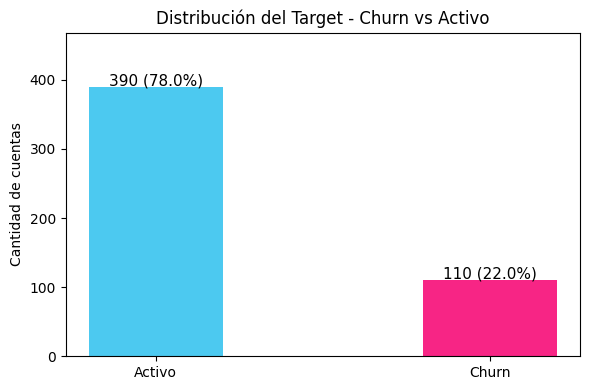

Cuentas activas : 390 (78.0%)
Cuentas en churn: 110 (22.0%)


In [15]:
# Distribución del target (churn vs activo)
conteo = df['target'].value_counts()
labels = ['Activo', 'Churn']
colores = ['#4cc9f0', '#f72585']

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, conteo.values, color=colores, width=0.4)

for bar, v in zip(bars, conteo.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

plt.title('Distribución del Target - Churn vs Activo')
plt.ylabel('Cantidad de cuentas')
plt.ylim(0, max(conteo.values) * 1.2)
plt.tight_layout()
plt.show()

print(f"Cuentas activas : {conteo[0]} ({conteo[0]/len(df)*100:.1f}%)")
print(f"Cuentas en churn: {conteo[1]} ({conteo[1]/len(df)*100:.1f}%)")

### Análisis Univariado - Variables Categóricas

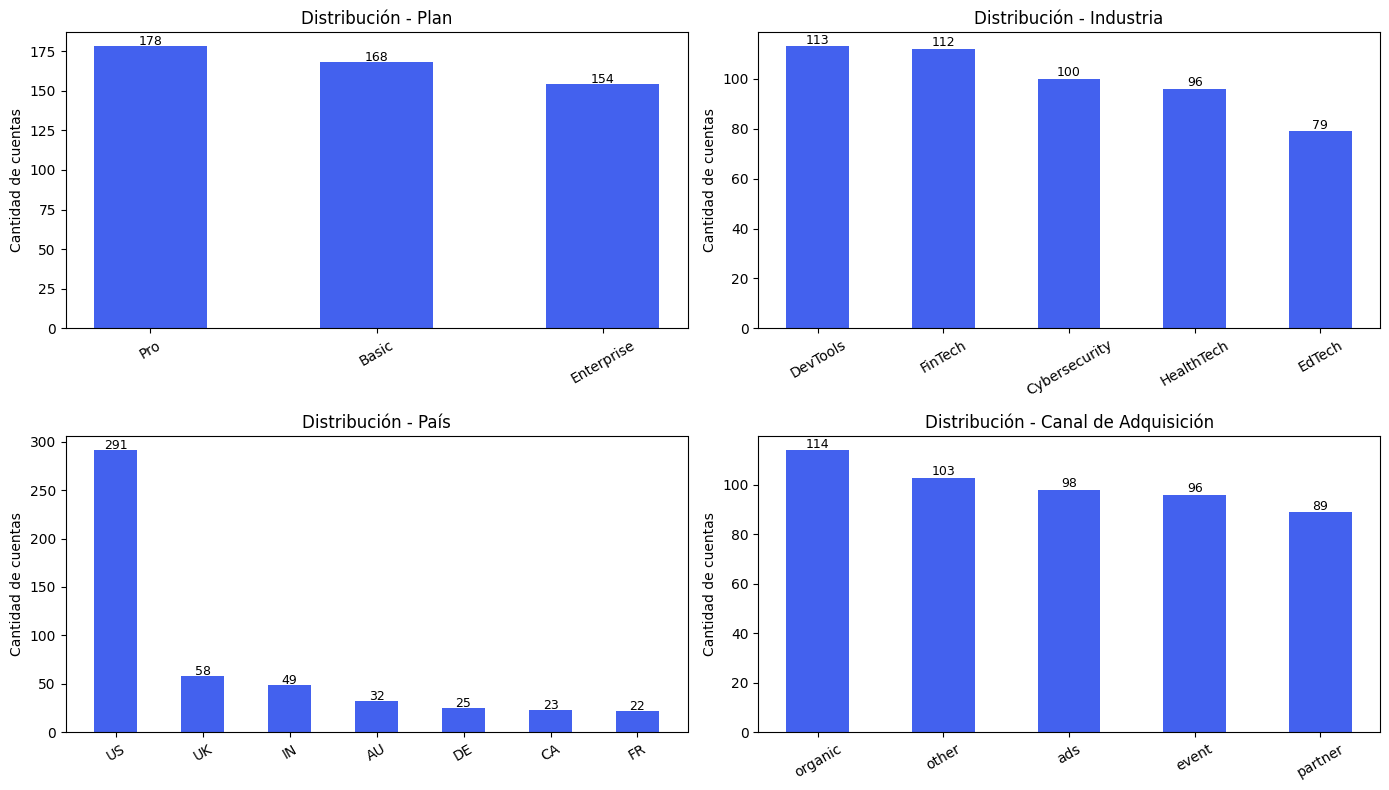

In [16]:
# Distribución de variables categóricas
categoricas = ['plan_tier', 'industry', 'country', 'referral_source']
titulos     = ['Plan', 'Industria', 'País', 'Canal de Adquisición']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col, titulo in zip(axes, categoricas, titulos):
    conteo = df[col].value_counts()
    ax.bar(conteo.index, conteo.values, color='#4361ee', width=0.5)
    ax.set_title(f'Distribución - {titulo}')
    ax.set_ylabel('Cantidad de cuentas')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(conteo.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Análisis Univariado - Variables Numéricas

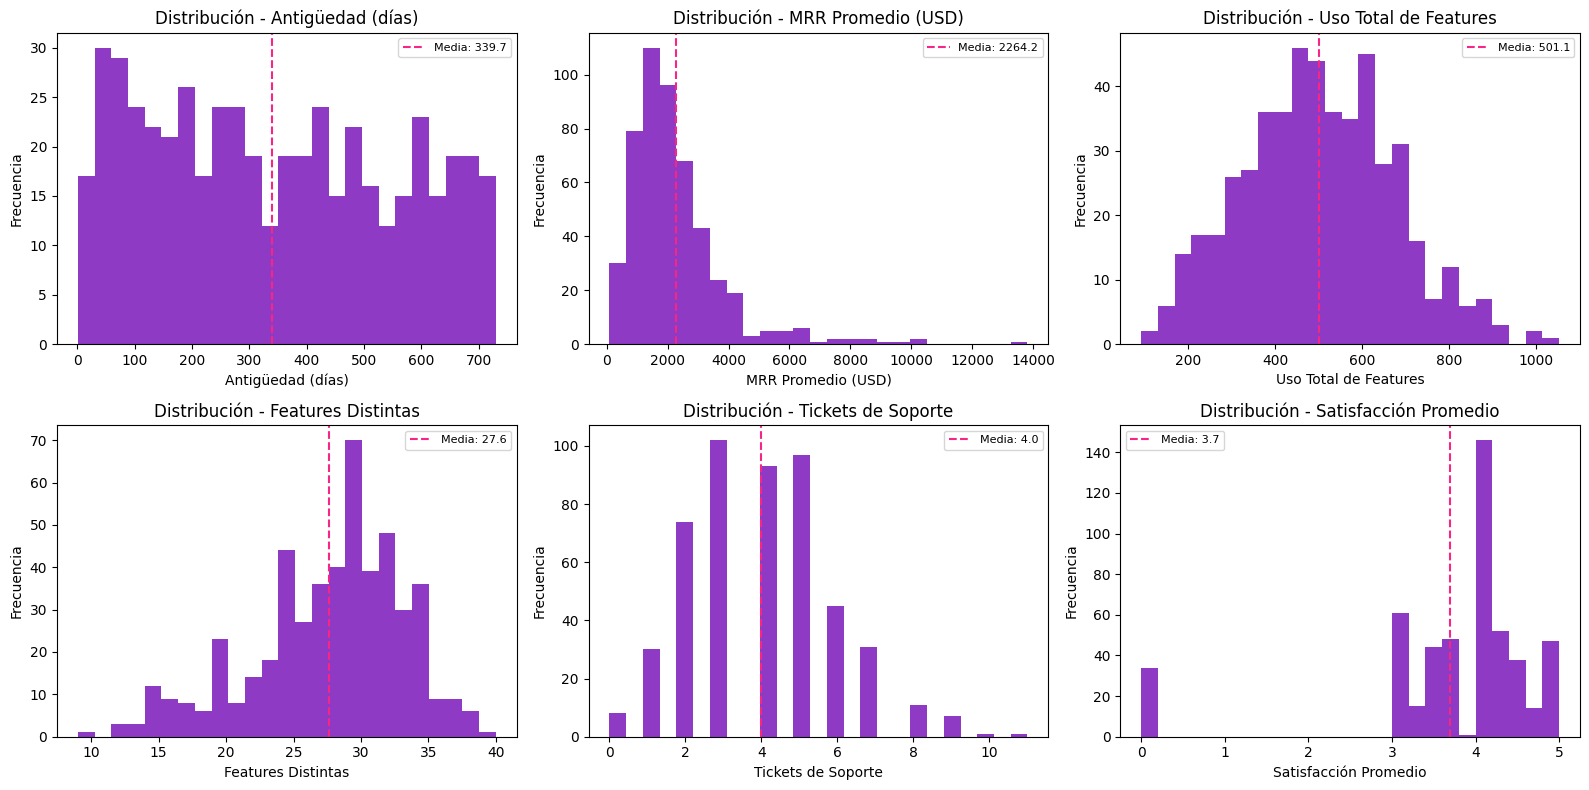

In [17]:
# Distribución de variables numéricas clave
numericas = ['tenure_days', 'avg_mrr', 'total_uso',
             'features_distintas', 'total_tickets', 'avg_satisfaccion']
titulos   = ['Antigüedad (días)', 'MRR Promedio (USD)', 'Uso Total de Features',
             'Features Distintas', 'Tickets de Soporte', 'Satisfacción Promedio']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col, titulo in zip(axes, numericas, titulos):
    ax.hist(df[col], bins=25, color='#7209b7', edgecolor='none', alpha=0.8)
    ax.set_title(f'Distribución - {titulo}')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frecuencia')
    ax.axvline(df[col].mean(), color='#f72585', linestyle='--',
               linewidth=1.5, label=f'Media: {df[col].mean():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Análisis Bivariado - Variables Categóricas vs Churn

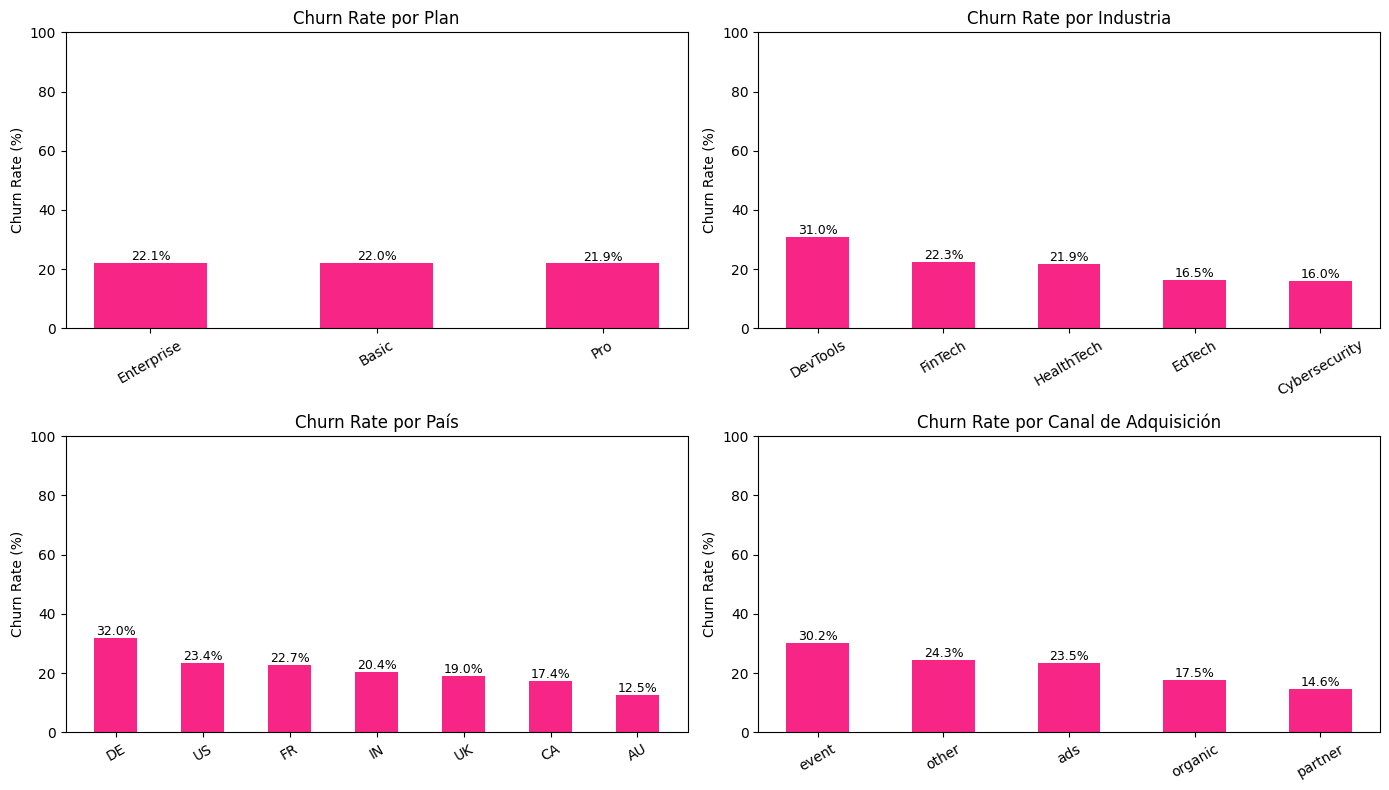

In [18]:
# Churn rate por variable categórica
categoricas = ['plan_tier', 'industry', 'country', 'referral_source']
titulos     = ['Plan', 'Industria', 'País', 'Canal de Adquisición']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col, titulo in zip(axes, categoricas, titulos):
    churn_rate = df.groupby(col)['target'].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values, color='#f72585', width=0.5)
    ax.set_title(f'Churn Rate por {titulo}')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 100)
    for bar, v in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1,
                f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Análisis Bivariado - Variables Numéricas vs Churn

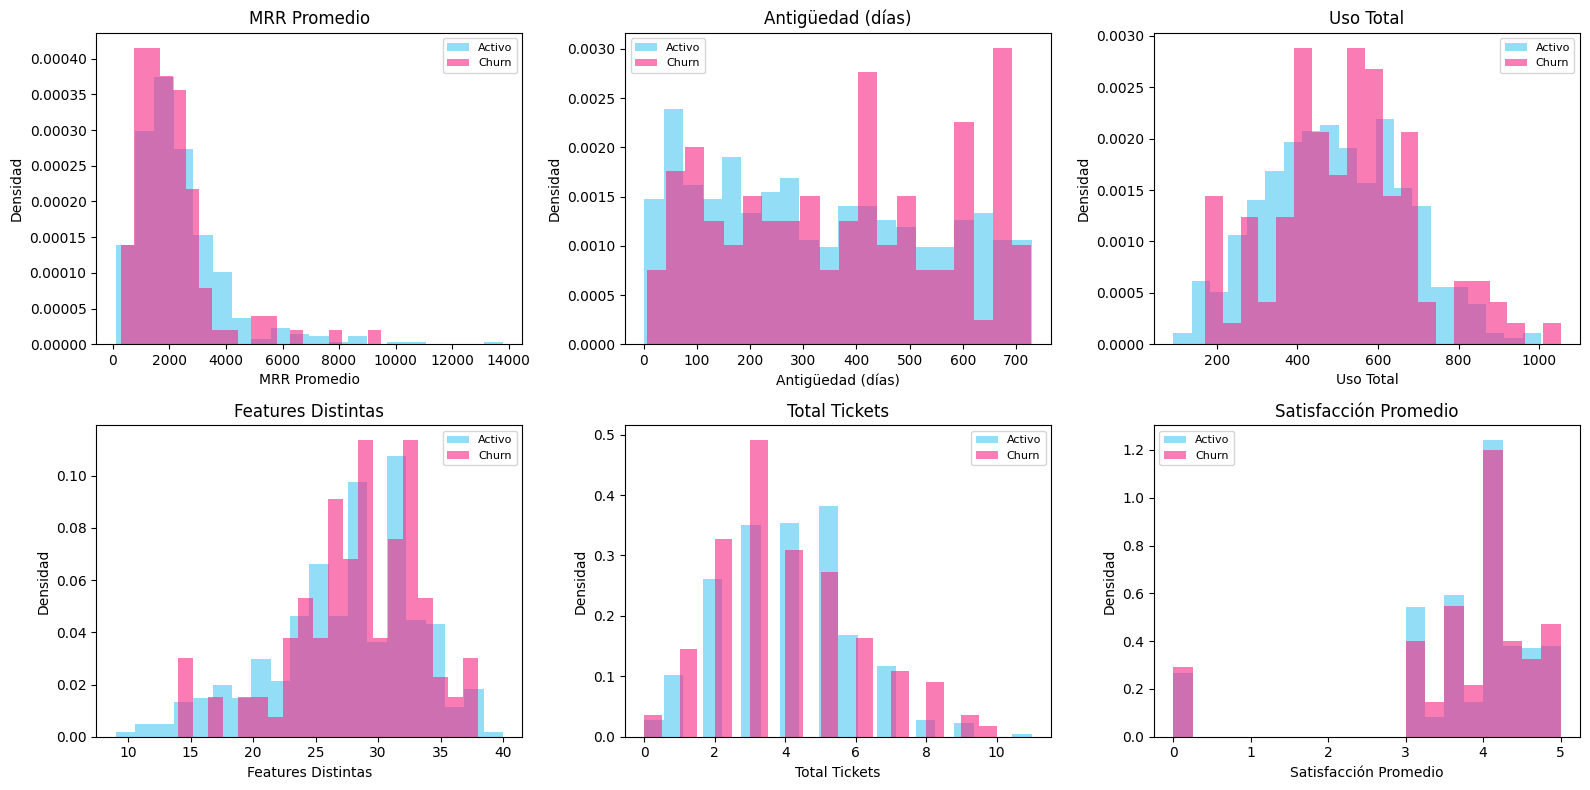

In [19]:
# Comparación de variables numéricas entre cuentas activas y en churn
numericas = ['avg_mrr', 'tenure_days', 'total_uso',
             'features_distintas', 'total_tickets', 'avg_satisfaccion']
titulos   = ['MRR Promedio', 'Antigüedad (días)', 'Uso Total',
             'Features Distintas', 'Total Tickets', 'Satisfacción Promedio']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col, titulo in zip(axes, numericas, titulos):
    data_activo = df[df['target'] == 0][col]
    data_churn  = df[df['target'] == 1][col]

    ax.hist(data_activo, bins=20, alpha=0.6, color='#4cc9f0',
            label='Activo', density=True)
    ax.hist(data_churn,  bins=20, alpha=0.6, color='#f72585',
            label='Churn',  density=True)

    ax.set_title(titulo)
    ax.set_xlabel(titulo)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Análisis Multivariado - Matriz de Correlaciones

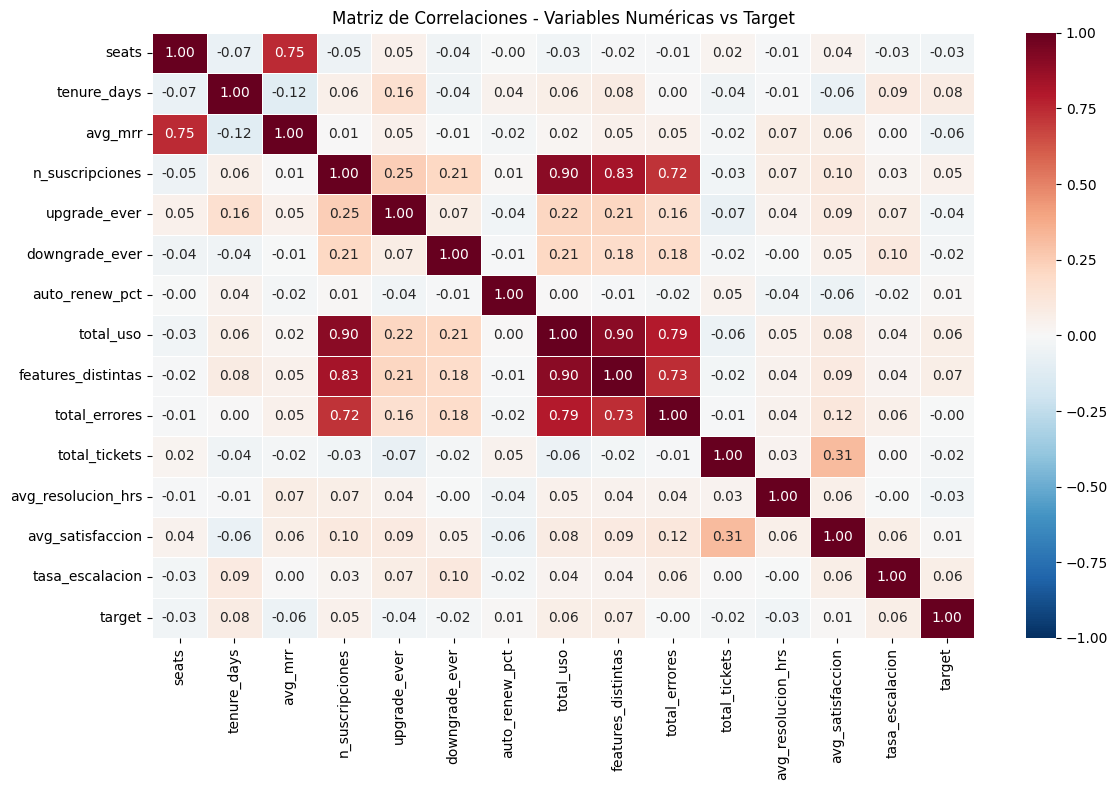

In [20]:
# Correlación entre variables numéricas y el target
cols_corr = ['seats', 'tenure_days', 'avg_mrr', 'n_suscripciones',
             'upgrade_ever', 'downgrade_ever', 'auto_renew_pct',
             'total_uso', 'features_distintas', 'total_errores',
             'total_tickets', 'avg_resolucion_hrs', 'avg_satisfaccion',
             'tasa_escalacion', 'target']

matriz = df[cols_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlaciones - Variables Numéricas vs Target')
plt.tight_layout()
plt.show()

### Conclusiones del EDA

El análisis exploratorio revela los siguientes patrones sobre el dataset:

- **Dataset desbalanceado:** 78% de las cuentas son activas y 22% hicieron churn.
  Este desbalance debe considerarse en la evaluación del modelo - un clasificador
  que prediga siempre "activo" tendría 78% de accuracy sin aprender nada.

- **El plan no predice churn:** los tres niveles (Basic, Pro, Enterprise) tienen
  tasas de churn casi idénticas (~22%). Esta variable tendrá baja importancia
  en el modelo.

- **Segmentos con mayor churn:** DevTools (31%) lidera por industria;
  Alemania (32%) por país; y el canal event (30.2%) por canal de adquisición.
  Son segmentos a monitorear.

- **Las variables numéricas no discriminan claramente entre clases:**
  MRR, antigüedad, uso de features y tickets muestran distribuciones muy
  similares entre cuentas activas y en churn. Esto sugiere que el churn
  en este dataset no responde a un patrón simple y lineal.

- **Correlaciones muy bajas con el target:** ninguna variable supera 0.08
  de correlación con `churn_flag`. El modelo deberá capturar interacciones
  entre variables, no efectos individuales, lo que favorece al Árbol de
  Decisión sobre métodos lineales.

- **Multicolinealidad en variables de uso:** `total_uso`, `features_distintas`,
  `total_errores` y `n_suscripciones` están muy correlacionadas entre sí
  (0.72–0.90). Aportan información redundante al modelo.

---
> **Conclusión general:** Dado que ninguna variable individual predice el churn
> de forma clara, el modelo deberá detectar combinaciones de condiciones —
> lo que refuerza la elección del Árbol de Decisión como algoritmo principal.

### 3.3 - Transformaciones para el Modelado

Una vez comprendidos los datos, aplicamos las transformaciones necesarias
para que los algoritmos puedan procesarlos correctamente.

#### Encoding de Variables Categóricas

Las variables `industry`, `country`, `referral_source` y `plan_tier` son categóricas
- contienen texto. Debido a que el modelo principal no interpreta relaciones ordinales decidimos convertirlas a
valores numéricos usando `LabelEncoder` de scikit-learn.

`LabelEncoder` asigna un número entero a cada categoría única. Por ejemplo:
- Basic → 0, Enterprise → 1, Pro → 2

Es importante aclarar que este encoding es adecuado para modelos basados en árboles
(como el que usaremos), que no interpretan el orden de los números. Para modelos
lineales sería necesario usar otro tipo de metodologia en su lugar.

In [21]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['industry', 'country', 'referral_source', 'plan_tier']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f"{col:20s} → categorías: {list(le.classes_)}")

industry             → categorías: ['Cybersecurity', 'DevTools', 'EdTech', 'FinTech', 'HealthTech']
country              → categorías: ['AU', 'CA', 'DE', 'FR', 'IN', 'UK', 'US']
referral_source      → categorías: ['ads', 'event', 'organic', 'other', 'partner']
plan_tier            → categorías: ['Basic', 'Enterprise', 'Pro']


### 3.4 - Selección de Features

No todas las columnas del dataset son útiles para el modelo. Descartamos:

- `account_id`, `account_name`: identificadores, no aportan información predictiva.
- `signup_date`: ya capturada en `tenure_days`.
- `churn_flag`: es el target en formato booleano, reemplazada por `target`.
- `industry`, `country`, `referral_source`, `plan_tier`: reemplazadas por sus
  versiones encoded.

Las variables que entran al modelo son:

In [22]:
FEATURES = [
    # Contrato
    'seats', 'tenure_days', 'is_trial',
    'avg_mrr', 'n_suscripciones',
    'upgrade_ever', 'downgrade_ever', 'auto_renew_pct',
    # Uso del producto
    'total_uso', 'features_distintas', 'total_errores', 'pct_beta',
    # Soporte
    'total_tickets', 'avg_resolucion_hrs', 'avg_satisfaccion', 'tasa_escalacion',
    # Categóricas encoded
    'industry_enc', 'country_enc', 'referral_source_enc', 'plan_tier_enc'
]

X = df[FEATURES]
y = df['target']

print(f"Features seleccionadas : {len(FEATURES)}")
print(f"Registros              : {len(X)}")
print(f"Distribución del target: {y.value_counts().to_dict()}")

Features seleccionadas : 20
Registros              : 500
Distribución del target: {0: 390, 1: 110}


### 3.5 - División Train/Test

Dividimos el dataset en dos subconjuntos:

- **Train (75%):** el modelo aprende los patrones a partir de estos datos.
- **Test (25%):** evaluamos el modelo sobre datos que nunca vio durante el entrenamiento.

Usamos `stratify=y` para garantizar que la proporción de churn sea la misma
en ambos subconjuntos. Sin esto, por azar podría quedar un subconjunto con
muchos más churns que el otro, sesgando la evaluación.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("=== DIVISIÓN TRAIN / TEST ===\n")
print(f"  Train → {len(X_train)} registros | Churn: {y_train.mean()*100:.1f}%")
print(f"  Test  → {len(X_test)}  registros | Churn: {y_test.mean()*100:.1f}%")

=== DIVISIÓN TRAIN / TEST ===

  Train → 375 registros | Churn: 22.1%
  Test  → 125  registros | Churn: 21.6%


### 3.6 - Normalización de Variables (requerida para KNN)

Algunos algoritmos como KNN calculan distancias entre registros.
Si una variable tiene valores entre 0 y 500 (como `tenure_days`) y otra
entre 0 y 1 (como `pct_beta`), la primera domina el cálculo de distancia
simplemente por su escala, no por su importancia real.

`StandardScaler` resuelve esto transformando cada variable para que tenga
media 0 y desvío estándar 1. El Árbol de Decisión no lo necesita,
pero lo aplicamos para tener ambos datasets disponibles.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Normalización aplicada.")
print(f"  Media   (primer feature): {X_train_scaled[:, 0].mean():.4f}")
print(f"  Desvío  (primer feature): {X_train_scaled[:, 0].std():.4f}")

Normalización aplicada.
  Media   (primer feature): -0.0000
  Desvío  (primer feature): 1.0000


## Fase #4 - Modelado / Modeling

En esta fase seleccionamos y entrenamos algoritmos de Machine Learning para
predecir si una cuenta va a hacer churn o no. Cuando un modelo no da buenos
resultados, es normal volver a la Fase 3 para ajustar las variables o las
transformaciones - CRISP-DM es un proceso iterativo, no lineal.

En esta fase:

- (4.1) **Selección de variable objetivo:** `churn_flag` como target binario (0/1)
- (4.2) **Selección de algoritmos:** Árbol de Decisión y KNN
- (4.3) **Calibración:** Búsqueda de parámetro óptimo para cada algoritmo (profundidad y K)
- (4.4) **Implementacion/Entrenamiento:** Implementacion y posterior ajuste de cada modelo sobre el conjunto de train
- (4.5) **Comparación:** Evaluación de accuracy train/test para seleccionar el mejor modelo

### 4.1 - Variable Objetivo

La variable objetivo del estudio es **`churn_flag`**, representada numéricamente
como `target` (0 = activo, 1 = churn).

El problema es de **clasificación binaria**: dado un conjunto de características
de una cuenta (plan, uso, soporte, antigüedad, etc.), el modelo debe decidir
a cuál de las dos categorías pertenece.

### 4.2 - Algoritmos Seleccionados

Aplicamos dos algoritmos y comparamos sus resultados:

#### **Método 1 - Árbol de Decisión:**
##### ¿Por qué Árbol de Decisión?

- Es fácil de interpretar y visualizar - se puede ver exactamente qué
  decisiones toma el modelo.
- No requiere normalización de variables numéricas.
- Maneja bien variables mixtas (numéricas y categóricas encoded).
- Es el algoritmo más didáctico para entender cómo funciona la clasificación.

##### ¿Cómo funciona?

El algoritmo divide los datos en grupos sucesivos haciendo preguntas
del tipo *"¿el MRR promedio es menor a X?"*. En cada división elige
la pregunta que mejor separa los churns de los activos.
El resultado es un árbol de decisiones que termina en hojas que
predicen la clase final.

El parámetro `max_depth` controla la profundidad máxima del árbol.
Un árbol muy profundo memoriza los datos de entrenamiento (overfitting);
uno muy superficial no captura suficiente información (underfitting).
Probamos distintas profundidades para encontrar la óptima.

#### **Método 2 - K-Nearest Neighbors (KNN):**
Para predecir si una cuenta va a hacer churn, busca las K cuentas más
similares en el dataset de entrenamiento y vota por mayoría.

##### ¿Por qué KNN?
Es útil para este problema porque:
- Es intuitivo: una cuenta se comporta de forma similar a las cuentas
  que se le parecen.
- No hace suposiciones sobre la distribución de los datos.
- Requiere normalización previa, que ya aplicamos en la Fase 3.

##### ¿Cómo funciona?
Dado un registro nuevo, calcula la distancia a todos los
registros de entrenamiento, selecciona los K más cercanos y asigna la clase
que tenga más votos entre ellos. Si 5 de los 7 vecinos más cercanos hicieron
churn, predice churn.

El parámetro `n_neighbors` controla cuántos vecinos consulta para votar.
Un K muy chico es sensible al ruido (overfitting); un K muy grande
pierde precisión local (underfitting). Probamos un rango para encontrar el óptimo.

### 4.3 Calibración de Parámetros

Cada algoritmo tiene un parámetro principal que controla su complejidad:
- Árbol de Decisión → `max_depth`: profundidad máxima del árbol.
- KNN → `n_neighbors`: cantidad de vecinos a consultar.

En ambos casos probamos un rango de valores y seleccionamos el que
maximiza el accuracy sobre el conjunto de test.

### 4.4 - Método 1: Árbol de Decisión

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Probamos distintas profundidades para encontrar la óptima
print("=== BÚSQUEDA DE PROFUNDIDAD ÓPTIMA ===\n")
print(f"  {'Profundidad':>12} | {'Accuracy Train':>15} | {'Accuracy Test':>14}")
print("  " + "-" * 47)

resultados = []

for profundidad in range(1, 9):
    modelo = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
    modelo.fit(X_train, y_train)

    acc_train = modelo.score(X_train, y_train)
    acc_test  = modelo.score(X_test,  y_test)

    resultados.append((profundidad, acc_train, acc_test))
    print(f"  {profundidad:>12} | {acc_train*100:>14.1f}% | {acc_test*100:>13.1f}%")


=== BÚSQUEDA DE PROFUNDIDAD ÓPTIMA ===

   Profundidad |  Accuracy Train |  Accuracy Test
  -----------------------------------------------
             1 |           77.9% |          78.4%
             2 |           78.1% |          78.4%
             3 |           78.4% |          78.4%
             4 |           80.0% |          70.4%
             5 |           82.1% |          72.0%
             6 |           84.3% |          71.2%
             7 |           86.4% |          69.6%
             8 |           88.5% |          60.8%


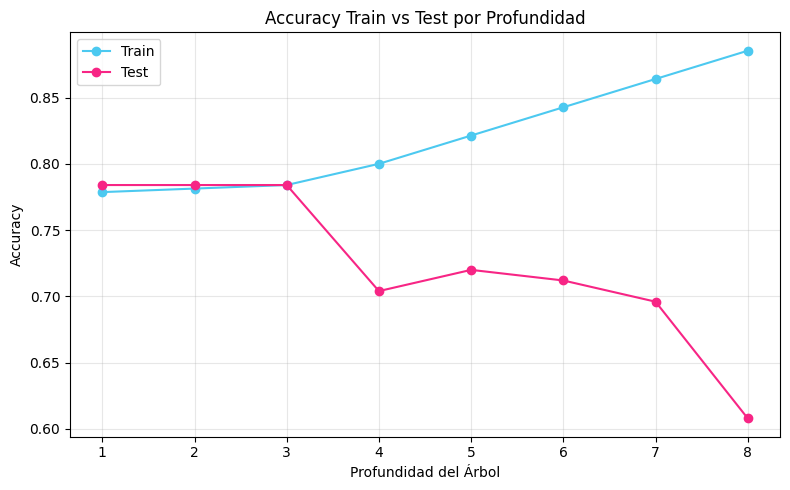

In [26]:
# Visualización de accuracy por profundidad
profundidades  = [r[0] for r in resultados]
acc_trains     = [r[1] for r in resultados]
acc_tests      = [r[2] for r in resultados]

plt.figure(figsize=(8, 5))
plt.plot(profundidades, acc_trains, marker='o', label='Train', color='#4cc9f0')
plt.plot(profundidades, acc_tests,  marker='o', label='Test',  color='#f72585')
plt.xlabel('Profundidad del Árbol')
plt.ylabel('Accuracy')
plt.title('Accuracy Train vs Test por Profundidad')
plt.legend()
plt.xticks(profundidades)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




A partir del análisis anterior seleccionamos la profundidad donde el
accuracy de test es más alto sin que train y test se separen demasiado
- señal de overfitting.

Entrenamos el modelo final con esa profundidad.

In [27]:
# Modelo final con la profundidad óptima
# Ajustá el valor de max_depth según el resultado del gráfico anterior
mejor_profundidad = 4

modelo_final = DecisionTreeClassifier(max_depth=mejor_profundidad, random_state=42)
modelo_final.fit(X_train, y_train)

print(f"Modelo entrenado con profundidad: {mejor_profundidad}")
print(f"Accuracy en Train : {modelo_final.score(X_train, y_train)*100:.1f}%")
print(f"Accuracy en Test  : {modelo_final.score(X_test,  y_test)*100:.1f}%")

Modelo entrenado con profundidad: 4
Accuracy en Train : 80.0%
Accuracy en Test  : 70.4%


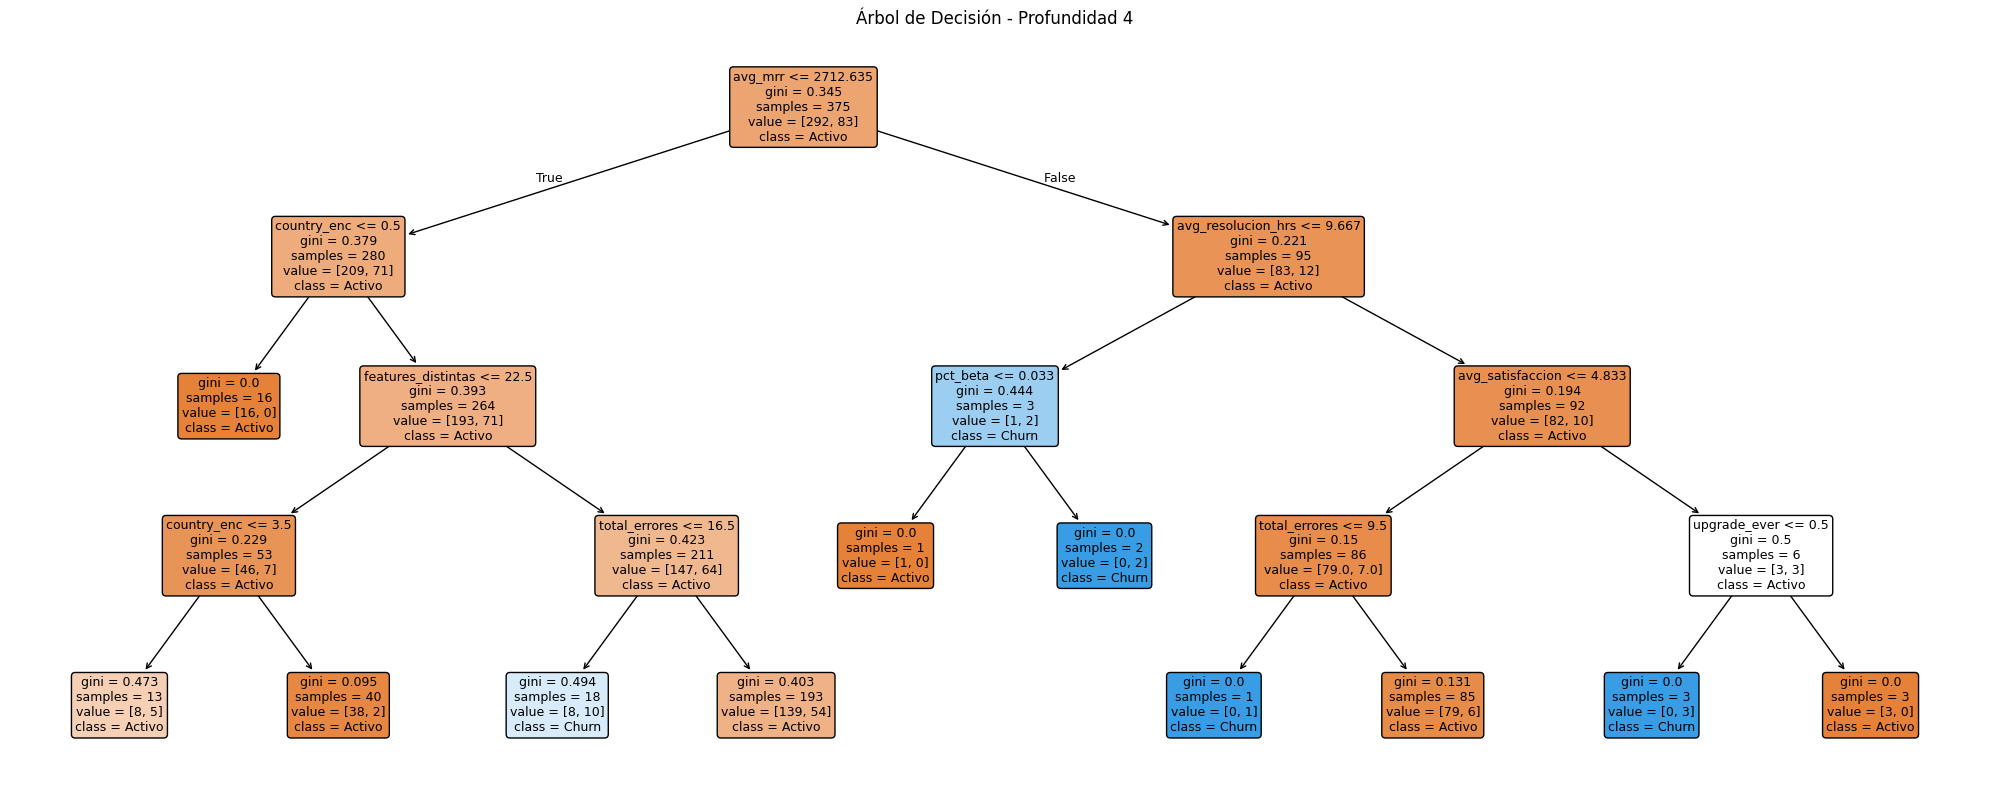

In [28]:
# Visualización del árbol de decisión
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(modelo_final,
          feature_names=FEATURES,
          class_names=['Activo', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=9)
plt.title(f'Árbol de Decisión - Profundidad {mejor_profundidad}')
plt.tight_layout()
plt.show()

### 4.4 - Método 2: K-Nearest Neighbors (KNN)

In [29]:
from sklearn.neighbors import KNeighborsClassifier

# Probamos distintos valores de K
print("=== BÚSQUEDA DE K ÓPTIMO ===\n")
print(f"  {'K (vecinos)':>12} | {'Accuracy Train':>15} | {'Accuracy Test':>14}")
print("  " + "-" * 47)

resultados_knn = []

for k in range(3, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    acc_train = knn.score(X_train_scaled, y_train)
    acc_test  = knn.score(X_test_scaled,  y_test)

    resultados_knn.append((k, acc_train, acc_test))
    print(f"  {k:>12} | {acc_train*100:>14.1f}% | {acc_test*100:>13.1f}%")

=== BÚSQUEDA DE K ÓPTIMO ===

   K (vecinos) |  Accuracy Train |  Accuracy Test
  -----------------------------------------------
             3 |           81.9% |          67.2%
             4 |           81.1% |          77.6%
             5 |           80.3% |          71.2%
             6 |           77.1% |          76.0%
             7 |           76.8% |          72.8%
             8 |           77.9% |          76.8%
             9 |           76.8% |          74.4%
            10 |           77.6% |          76.8%
            11 |           77.9% |          76.8%
            12 |           77.6% |          77.6%
            13 |           77.6% |          77.6%
            14 |           77.6% |          78.4%
            15 |           77.6% |          76.0%


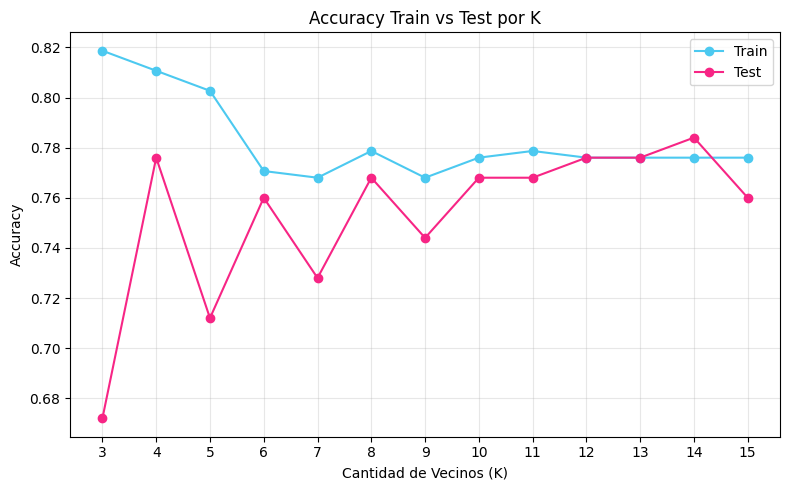

In [30]:
# Visualización accuracy por K
ks         = [r[0] for r in resultados_knn]
acc_trains = [r[1] for r in resultados_knn]
acc_tests  = [r[2] for r in resultados_knn]

plt.figure(figsize=(8, 5))
plt.plot(ks, acc_trains, marker='o', label='Train', color='#4cc9f0')
plt.plot(ks, acc_tests,  marker='o', label='Test',  color='#f72585')
plt.xlabel('Cantidad de Vecinos (K)')
plt.ylabel('Accuracy')
plt.title('Accuracy Train vs Test por K')
plt.legend()
plt.xticks(ks)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A partir del análisis anterior seleccionamos el K optimo, donde el
accuracy de test es más alto sin que train y test se separen demasiado
- señal de overfitting.

Entrenamos el modelo final con ese.

In [31]:
# Modelo KNN final con el K óptimo
# Ajustá el valor según el gráfico anterior
mejor_k = 7

knn_final = KNeighborsClassifier(n_neighbors=mejor_k)
knn_final.fit(X_train_scaled, y_train)

print(f"Modelo KNN entrenado con K = {mejor_k}")
print(f"Accuracy en Train : {knn_final.score(X_train_scaled, y_train)*100:.1f}%")
print(f"Accuracy en Test  : {knn_final.score(X_test_scaled,  y_test)*100:.1f}%")

Modelo KNN entrenado con K = 7
Accuracy en Train : 76.8%
Accuracy en Test  : 72.8%


### 4.5 - Comparación de Modelos

| Modelo | Parámetro | Accuracy Train | Accuracy Test |
|---|---|---|---|
| Árbol de Decisión | profundidad = 4 | 80.0% | 70.4% |
| KNN | K = 7 | 76.8% | 72.8% |

Se comparan los dos modelos implementados, el modelo con mayor Accuracy en Test y menor brecha con Train
es el que seleccionaremos para la Fase 5.

##Fase #5: Evaluación / Evaluation
En esta etapa del proyecto, ha construido un modelo (o modelos) que parece tener alta calidad desde una perspectiva de análisis de datos. Antes de proceder a la implementación final del modelo, es importante evaluar más a fondo el modelo y revisar los pasos realizados para construir el modelo y asegurarse de que logra correctamente los objetivos comerciales. Un objetivo clave es determinar si hay algún tema importante del negocio que no se hayaconsiderado lo suficiente. Al final de esta fase, se debe tomar una decisión sobre el uso de los resultados de la minería de datos.
* Investigá sobre las métricas que se utilizan para medir el modelo escogido.
* Evalúa dichas métricas en el modelo implementado e intenta explicarlas.

In [32]:
#Acá debés cargar las librerías con las que trabajarás en esta fase



In [33]:
#Acá debés poder validar el modelo, calcular las métricas
#y construir la matriz de confusión




##Fase #6: Despliegue (Deployment)
Por lo general, la creación del modelo no es el final del proyecto. Incluso si el propósito delmodelo es aumentar el conocimiento de los datos, el conocimiento adquirido deberá organizarse y presentarse de manera que el cliente pueda utilizarlo. A menudo implica laaplicación de modelos "en vivo" dentro de los procesos de toma de decisiones de una organización, por ejemplo, en la personalización en tiempo real de páginas web o la puntuación repetida de bases de datos de marketing. Sin embargo, en función de los requisitos, la fase de implementación puede ser tan sencilla como generar un informe o tan compleja como implementar un proceso de minería de datos repetible en toda la empresa. En muchos casos, es el cliente, no el analista de datos, quien lleva a cabo los pasos de implementación. Sin embargo, incluso si el analista no llevará a cabo el esfuerzo de implementación, es importante que el cliente comprenda de antemano qué acciones deben llevarse a cabo para hacer uso de los modelos creados.
* Definí un plan para mantener la solución actualizada y funcional. Proporcioná actualizaciones de seguridad y soluciona problemas según sea necesario.
* Colocá acá las vistas del software implementado y el link desde dónde se puede acceder para interactuar con el software (puede estar hardcodeado con las soluciones y gráficos que coloquen acá, en esta notebook).

###Aclaraciones:
* Buscá la síntesis. No nos interesan las largas explicaciones, sino la capacidad de sintetizar el problema.
* No te extiendas más de lo necesario. Utiliza tablas de resumen, herramientas gráficas. Sé creativo. Este no es un trabajo de conocimiento, es un trabajo de aplicación y comunicación de la estrategia.
* No hay respuestas incorrectas, solo problemas de negocio poco explorados 🙂